# Theory

1. select dorsal ventral gridnet associated genes (Bennet's csv):
    - p-vale less 0.05
    - abs(corr) more 0.1
2. log(norm) raw counts --> of **NOT perturbed** data
3. score = dot(log_norm, corr_selected_spatial_genes)
4. take adat **WITH pertubation**:
    - in **ONLY diseased samples** remove pct cells that are msot dorsal

**HIGH SCORE = MORE DORSAL**

In [1]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import pandas as pd
import numpy as np
import os
import gc

from utils import preprocessing
from utils import DEG
%matplotlib inline

ADATA_ALL_SAMPLES = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/zonated_objs_combined_with_md.h5ad"

# Attention the follwing adata mus be create .qs --> h5ad
ADATA_TO_CREATE_DEPLETED_VERSIONS = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1.0_raw.h5ad"
adata_to_create_depleyed_versions_folder = f"{os.path.split(ADATA_TO_CREATE_DEPLETED_VERSIONS)[0]}/depleted_versions/"
print(adata_to_create_depleyed_versions_folder)
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results

DEPLETION_PERCENTS = ["0.00", "0.01", "0.05", "0.10", "0.20", "0.30", "0.40", "0.50"]

CONTRAST_VARIABLE = "case_control"
CONTRAST_VARIABLE_HEALTHY = "control"
CONTRAST_VARIABLE_DISEASED = "case"
DONOR_ID_VARIABLE = "donor_id"
CT_COL = "spn_type"
CTS_TO_SUBSET = ["ventral_matrix", "dorsal_matrix"]

# PSUDOBULK paramters
COV_FOR_PSEUDOBULK = None #[celltype] #in addition top donor_id
# Obs col names that groups psudocells in groups in which perfomr DEG in them --> it is made using the var in COV_FOR_PSEUDOBULK
GROUP_DEG_COL = "pseudobulk_group_for_DEG"
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic"]
# Cov to have in pesudbulked data that are interesing to not òose
INTERESTING_COV = []
# Filter varibales for pseudobulk cells
MIN_CELLS_PER_PSUDOCELL=10
MIN_COUNTS_PER_PSEUDOCELL=1000
MIN_PSEUDOCELL_PER_GROUP=2
# Filter gens noisy/low expressed
MIN_COUNTS=10
LARGE_N=10
MIN_TOTAL_COUNTS=15
MIN_PROP_BY_EXPR=0.3
MIN_PROP_BY_PROP=0.1
MIN_SMPLS=2

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/


# Load

In [2]:
adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/zonated_objs_combined_with_md.h5ad",
    backed="r"
)

# Filter to only ventral and dorsal matrix
adata = adata[adata.obs[CT_COL].isin(CTS_TO_SUBSET)].to_memory().copy()

adata

AnnData object with n_obs × n_vars = 121633 × 37905
    obs: 'donor_id', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type'
    var: 'features'

# Calculate dorsal-ventral score

In [3]:
# Normalise
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [4]:
# Define gene sets
df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

# Select siognficant
df_grad = df_grad[(df_grad.combined_p <= 0.05) & (np.abs(df_grad.mean_spearman) >= 0.1)]

df_grad

,gene,mean_spearman,combined_p
58,ABCB9,-0.128768,9.992007e-16
72,ABCD2,-0.121525,9.992007e-16
88,ABHD12B,-0.213089,1.110223e-15
109,ABI3BP,0.213897,9.992007e-16
113,ABLIM1,0.296894,9.992007e-16
...,...,...,...
49169,ENSG00000285940,0.132392,9.992007e-16
49973,ENSG00000269825,0.149794,9.992007e-16
50526,ENSG00000289899,0.139389,9.992007e-16
51133,ENSG00000289084,-0.104954,9.992007e-16


1102 common genes
(121633, 1102)


<Axes: ylabel='Frequency'>

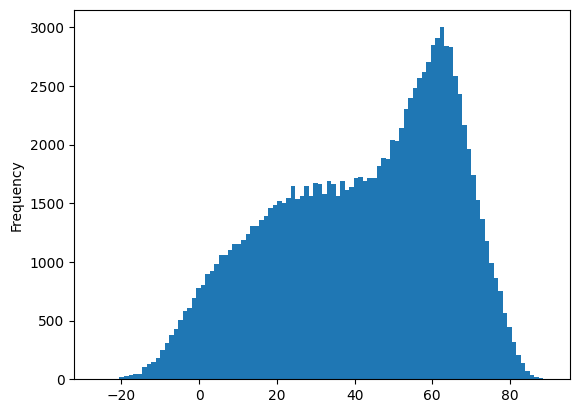

In [5]:
# calculate score per cell

common_genes = adata.var_names.intersection(df_grad.gene)
print(f"{len(common_genes)} common genes")

X_grad_genes = adata[:, common_genes].X  # (n_cells × n_genes)
print(X_grad_genes.shape)

df_grad = (
    df_grad
    .set_index("gene")
    .loc[common_genes]
)

# more dorsal genes --> higher score
adata.obs["gradient_score"] = - X_grad_genes @ df_grad.mean_spearman.values


adata.obs["gradient_score"].plot(kind="hist", bins=100)

# Make % depleted datasets

In [6]:
adata_pert_complete = sc.read_h5ad(
    ADATA_TO_CREATE_DEPLETED_VERSIONS,
    backed="r"
)

adata_pert_complete = adata_pert_complete[adata_pert_complete.obs[CT_COL].isin(CTS_TO_SUBSET)].to_memory().copy()

adata_pert_complete

AnnData object with n_obs × n_vars = 121633 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'P

0.00


/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


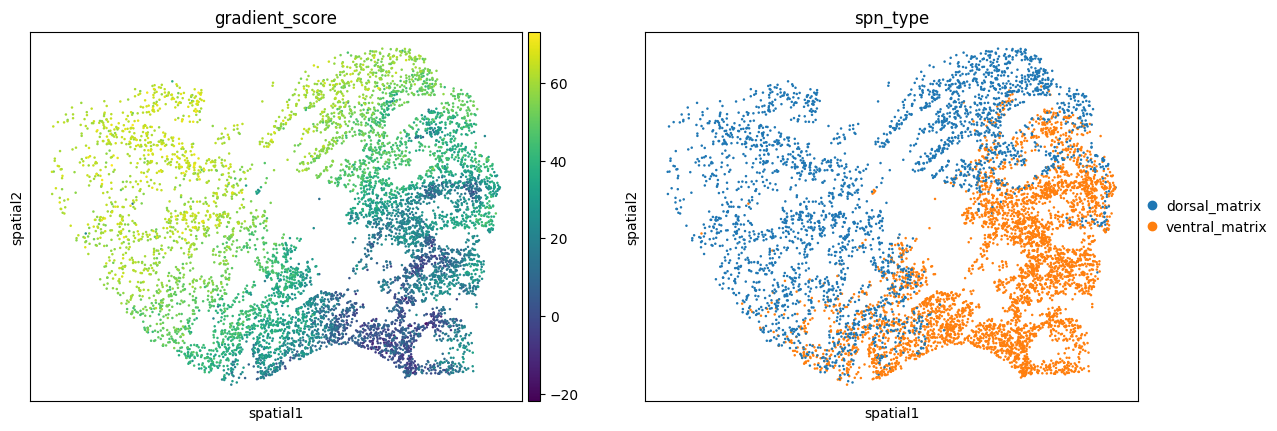


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.1110e+03 3.5510e+03 6.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2670e+03 5.4300e+03 1.5000e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0050e+03 5.9330e+03 1.0700e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


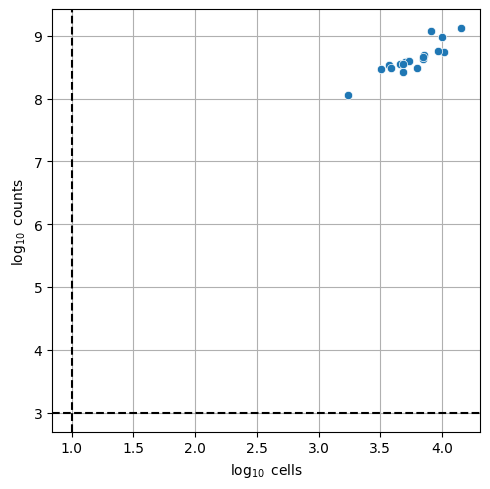

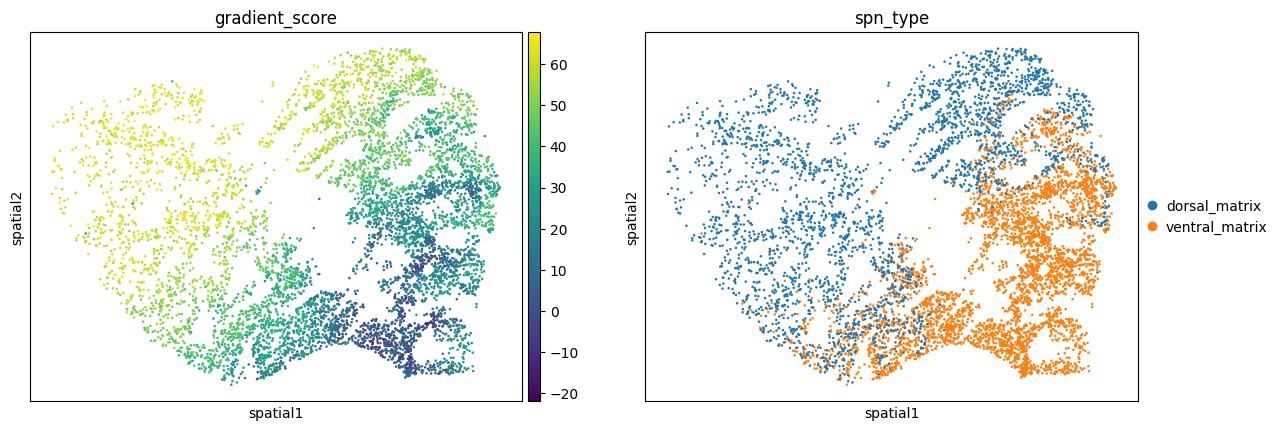


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.1050e+03 3.5150e+03 6.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2480e+03 5.3780e+03 1.4900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.9910e+03 5.8860e+03 1.0700e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


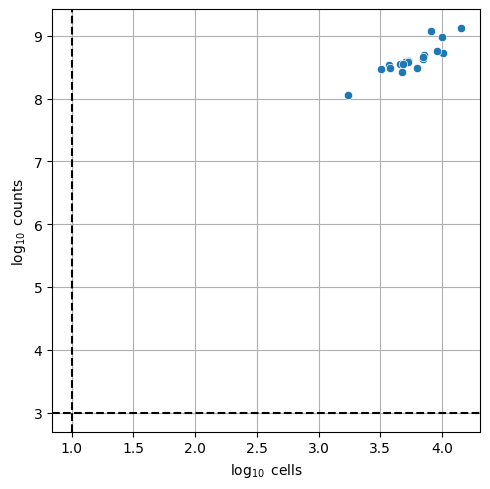

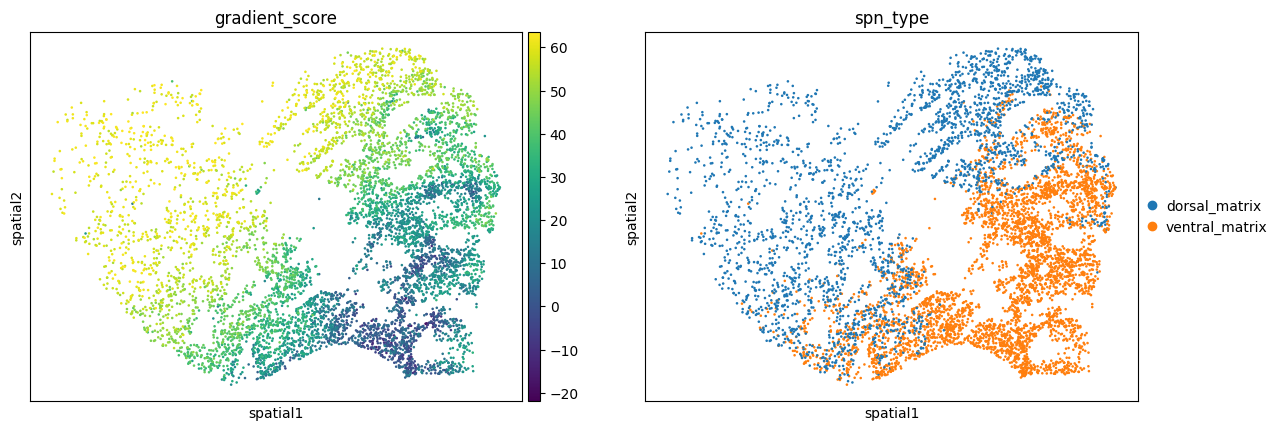


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.0750e+03 3.3800e+03 6.2000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.1640e+03 5.1430e+03 1.4200e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.9460e+03 5.6810e+03 1.0400e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


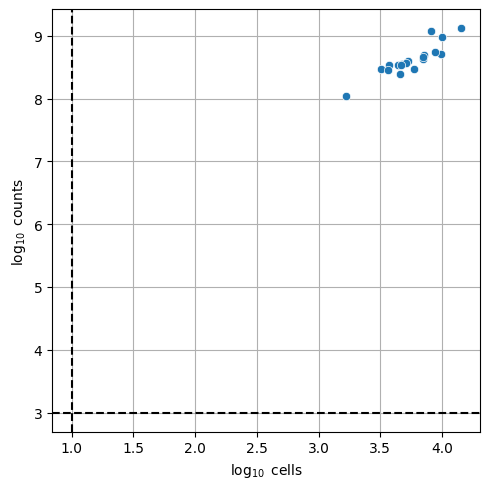

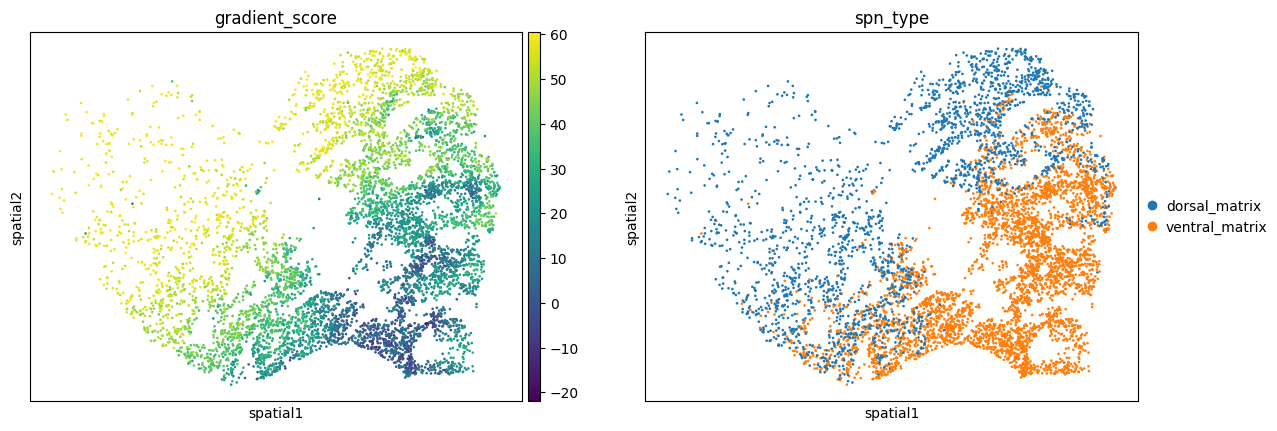


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [1.0240e+03 3.1760e+03 5.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.0600e+03 4.8740e+03 1.3900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.8720e+03 5.3950e+03 9.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


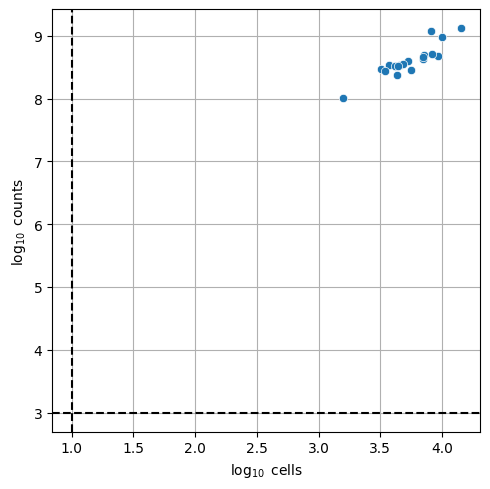

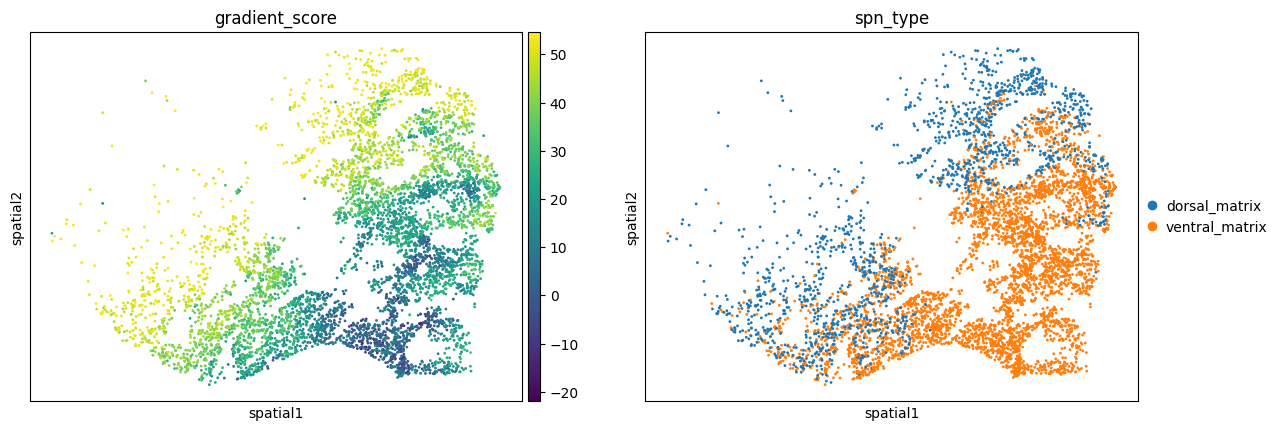


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [9.1200e+02 2.8490e+03 5.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.8620e+03 4.3160e+03 1.2900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.7230e+03 4.8520e+03 8.9000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


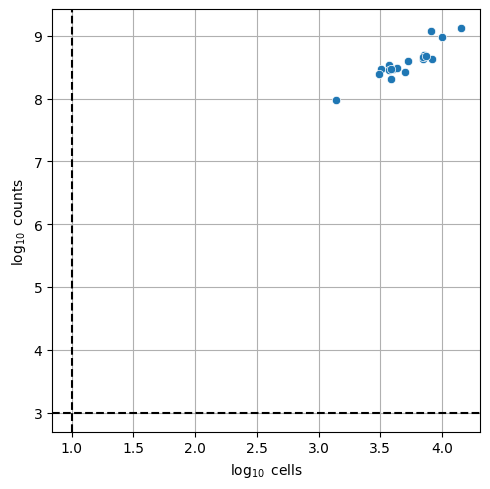

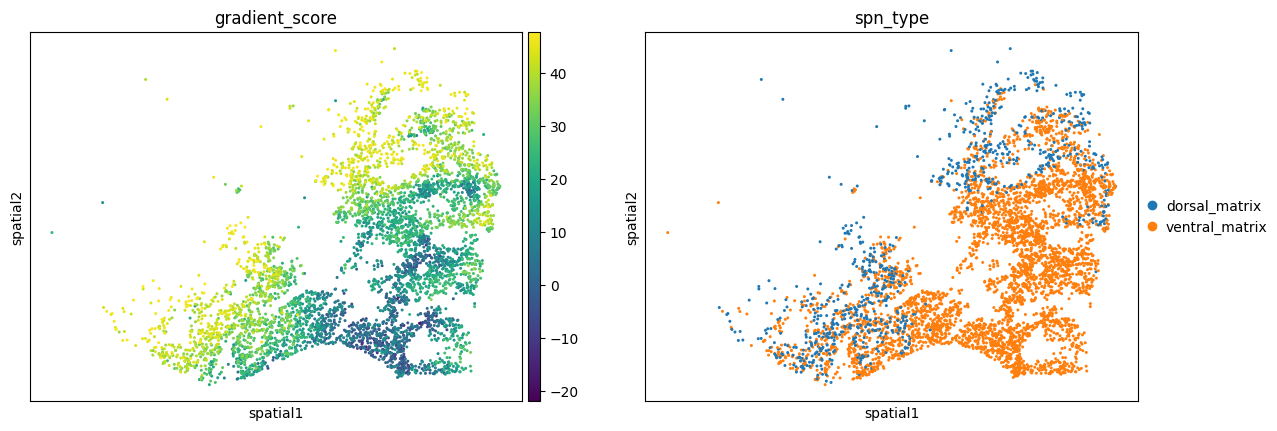


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [8.1700e+02 2.5100e+03 4.3000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.6260e+03 3.7590e+03 1.1300e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.5490e+03 4.2780e+03 8.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


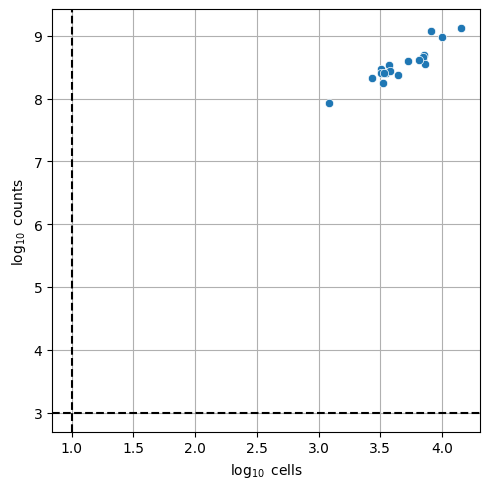

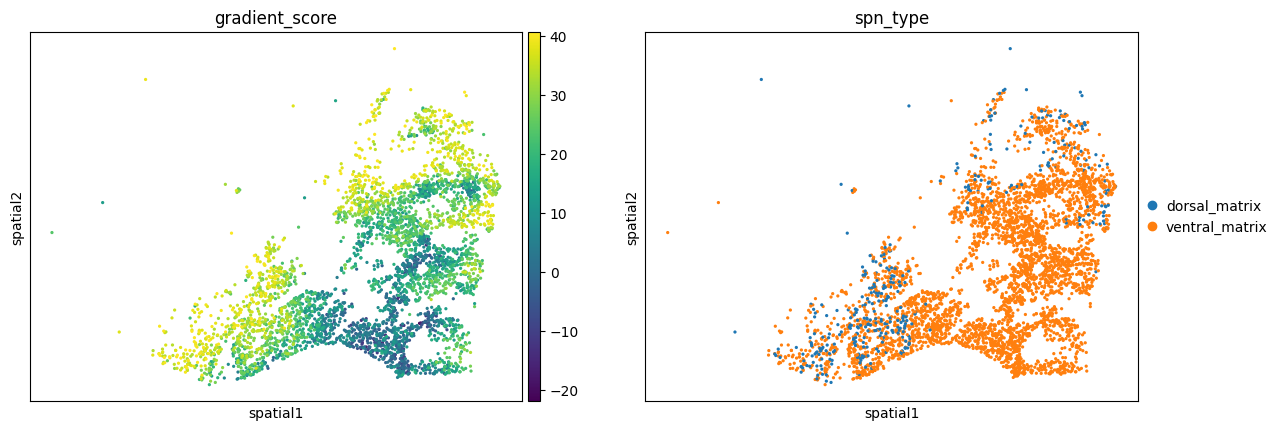


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [7.2100e+02 2.1440e+03 3.9000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.3980e+03 3.2100e+03 9.1000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.3850e+03 3.7280e+03 7.7000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

/tmp/ipykernel_9490/3480502699.py:55: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']


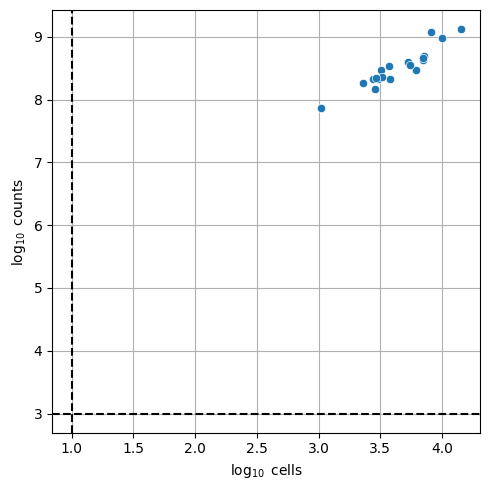

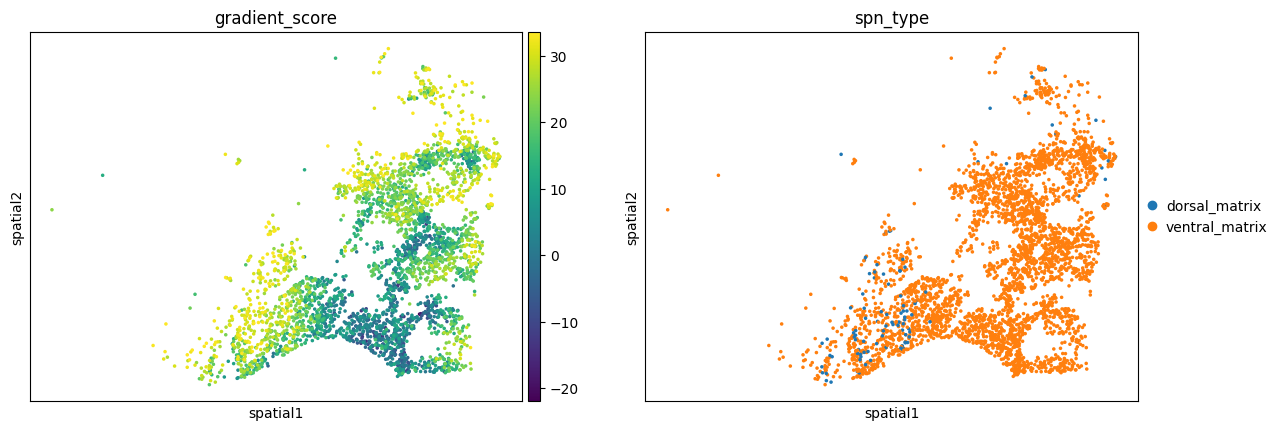


Psudobulking


/home/gdallagl/myworkdir/XDP/utils/DEG.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_zone_metadata = adata.obs.groupby(groupby_cols).agg(agg_dict)
... storing 'pseudobulk_group_for_DEG' as categorical


[[3.6110e+03 1.0126e+04 3.8800e+02 ... 0.0000e+00 1.0000e+00 0.0000e+00]
 [1.3730e+03 4.3150e+03 1.0500e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [2.2070e+03 5.1530e+03 1.0900e+02 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 ...
 [6.1400e+02 1.7550e+03 3.4000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.1840e+03 2.6530e+03 7.2000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.2160e+03 3.1400e+03 7.0000e+01 ... 0.0000e+00 0.0000e+00 0.0000e+00]]

Adding metadata
{'Age.at.Death': 'mean', 'Sex': 'first', 'PMI': 'mean', 'pct_mt': 'mean', 'pct_intronic': 'mean'}
                    donor_id  orig.ident pct_ribosomal experiment  \
pseudobulk_group                                                    
PT13935              PT13935  2024-10-25             0         s5   
UMBEB23073        UMBEB23073  2025-03-11             0        s12   
UMBEB23033        UMBEB23033  2025-03-18             0        s15   

                 Neighborhood_name Neighborhood_bootstrapping_probability  \
pseudobulk_group  

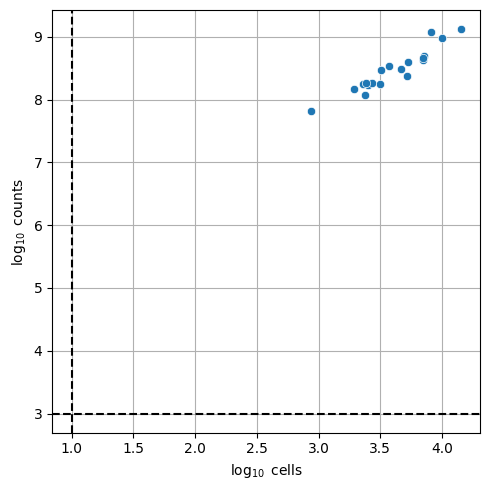

In [7]:

for pct in DEPLETION_PERCENTS:
    print(pct)

    save_folder = os.path.join(adata_to_create_depleyed_versions_folder, f"depleted_{pct}_dorsal_matrix",)
    save_path_h5ad = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.h5ad")
    save_path_pseudobulked = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix_pseudobulked.h5ad")
    save_path_qs = os.path.join(save_folder, f"depleted_{pct}_dorsal_matrix.qs")
    os.makedirs(save_folder, exist_ok=True)

    # if (os.path.exists(save_path_h5ad)) & (os.path.exists(save_path_qs)):
    #     print(f"\tFiles already exist, skipping...")
    #     continue

    # Add gradient score 
    obs = adata_pert_complete.obs.copy()
    obs_grad = adata.obs[["gradient_score"]].copy()
    obs = obs.merge(
        obs_grad,
        left_index=True,
        right_index=True,
        how="left", 
        validate="one_to_one"
    )
    
    # Get healthy cells (keep all)
    healthy_mask = obs[CONTRAST_VARIABLE] != CONTRAST_VARIABLE_DISEASED
    
    # Get diseased cells and their gradient scores
    diseased_mask = obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED
    diseased_obs = obs[diseased_mask].copy()
    
    # For each diseased sample, mark cells to keep
    cells_to_keep_mask = healthy_mask.copy()  # Start with all healthy cells
    
    for sample_id in diseased_obs[DONOR_ID_VARIABLE].unique():
        # Get cells from this sample
        sample_mask = (diseased_obs[DONOR_ID_VARIABLE] == sample_id)
        sample_cells = diseased_obs[sample_mask]
        
        # Calculate how many to keep
        n_cells = len(sample_cells)
        n_cells_to_keep = int(n_cells * (1 - float(pct)))
        
        # Sort by gradient score and get bottom cells to keep (remove the most dorsal)
        sorted_cells = sample_cells.sort_values('gradient_score')
        cells_to_keep_ids = sorted_cells.index[:n_cells_to_keep]   # Keeps LOWEST scores
        
        # Mark these cells to keep
        cells_to_keep_mask[cells_to_keep_ids] = True
    
    # Single subset operation on backed adata
    adata_pert_tmp = adata_pert_complete[cells_to_keep_mask]

    # Save scores
    adata_pert_tmp.obs['gradient_score'] = obs.loc[adata_pert_tmp.obs_names, 'gradient_score']

    # at the end of each lopp chekc one sample
    sample_id = "MS986638" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
    adata_s = adata_pert_tmp[adata_pert_tmp.obs[DONOR_ID_VARIABLE] == sample_id].to_memory().copy()
    adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])
    del adata_s


    # Save the subsetted adata
    adata_pert_tmp.write_h5ad(save_path_h5ad)

    ########################

    # CONVERT TO QS

    # print("\tSaving files for R coversion...")
    # preprocessing.save_files_for_R_conversion(adata_pert_tmp, QS_TMP_FOLDER)
    # print("\tBuilding R obj...")
    # preprocessing.build_qs_from_python_files(
    #     QS_TMP_FOLDER, saving_path=save_path_qs, 
    #     contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_VARIABLE_HEALTHY)

    #########################

    # SAVE PSEUDOBULK
    adata_pb_all = DEG.pseudobulk(adata_pert_tmp, DONOR_ID_VARIABLE, COV_FOR_PSEUDOBULK, GROUP_DEG_COL, COVARIATES_FOR_DEG=COVARIATES_FOR_DEG, INTERESTING_COV=INTERESTING_COV,
            MIN_CELLS_PER_PSUDOCELL=MIN_CELLS_PER_PSUDOCELL,MIN_COUNTS_PER_PSEUDOCELL=MIN_COUNTS_PER_PSEUDOCELL, filter_genes=True, layer=None,
            MIN_COUNTS=MIN_COUNTS,LARGE_N=LARGE_N, MIN_TOTAL_COUNTS=MIN_TOTAL_COUNTS, MIN_PROP_BY_EXPR=MIN_PROP_BY_EXPR,MIN_PROP_BY_PROP=MIN_PROP_BY_PROP,MIN_SMPLS=MIN_SMPLS, )
    adata_pb_all.write_h5ad(save_path_pseudobulked)
    
    del adata_pert_tmp, adata_pb_all
    gc.collect()

print("Done")

# Verify dorsal.gradient

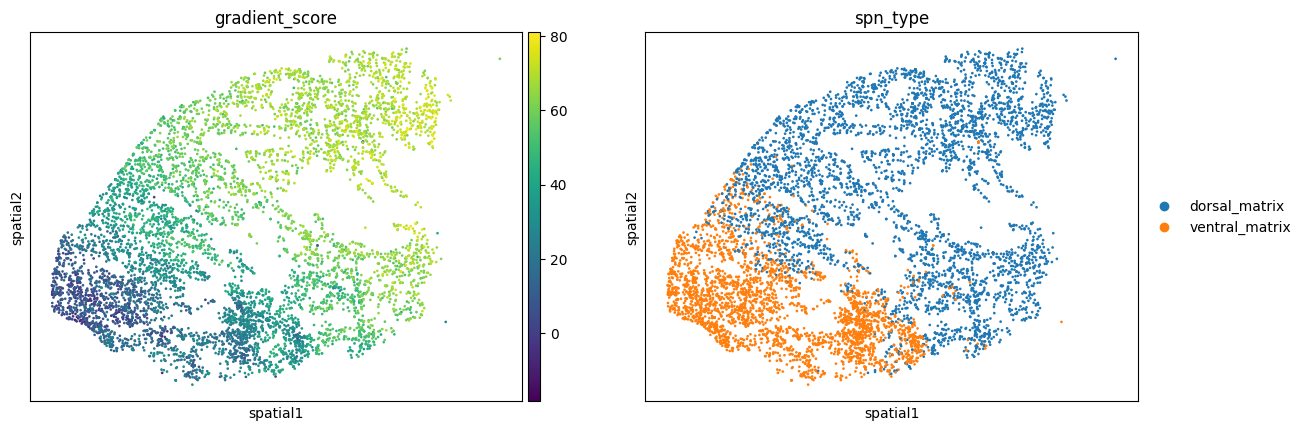

In [8]:
adata_s = adata_pert_complete[adata_pert_complete.obs.donor_id == "PT13935"].to_memory().copy()
adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
obs_grad = adata.obs[["gradient_score"]].copy()
adata_s.obs = adata_s.obs.merge(
    obs_grad,
    left_index=True,
    right_index=True,
    how="left", 
    validate="one_to_one"
)
sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])